In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')
col = 'volumen_agua_total_m3_ha'
data = df[col].dropna().values

# --- Ajuste log-normal ---
shape, loc, scale = stats.lognorm.fit(data, floc=0)
mu_ln = np.log(scale)
sigma_ln = shape

# --- Prueba KS ---
ks_stat, ks_pval = stats.kstest(data, 'lognorm', args=(shape, loc, scale))

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2, 1.5, 1.5])

ax1 = fig.add_subplot(gs[0])
ax1.hist(data, bins=40, density=True, color='steelblue',
         edgecolor='white', linewidth=0.5, alpha=0.75, label='Datos empíricos')
x = np.linspace(data.min(), data.max(), 400)
ax1.plot(x, stats.lognorm.pdf(x, shape, loc, scale),
         color='tomato', linewidth=2, label=f'Log-normal ajustada\n μ={mu_ln:.2f}, σ={sigma_ln:.2f}')
ax1.axvline(data.mean(), color='gold', linestyle='--', linewidth=1.4, label=f'Media: {data.mean():,.0f}')
ax1.axvline(np.median(data), color='lime', linestyle='--', linewidth=1.4, label=f'Mediana: {np.median(data):,.0f}')
ax1.axvspan(6000, 8000, alpha=0.07, color='green')
ax1.set_title('Histograma + ajuste log-normal', fontsize=11, fontweight='bold')
ax1.set_xlabel('Volumen total (m³/ha)', fontsize=9)
ax1.set_ylabel('Densidad', fontsize=9)
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1])
cultivos = df['cultivo'].unique()
data_by_cultivo = [df.loc[df['cultivo'] == c, col].dropna().values for c in cultivos]
bp = ax2.boxplot(data_by_cultivo, patch_artist=True, medianprops=dict(color='gold', linewidth=2))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xticklabels(cultivos, fontsize=8, rotation=20)
ax2.set_title('Consumo por cultivo', fontsize=11, fontweight='bold')
ax2.set_ylabel('Volumen total (m³/ha)', fontsize=9)
ax2.axhline(8000, color='tomato', linestyle=':', linewidth=1.2, label='Baseline 8,000')
ax2.axhline(6000, color='green', linestyle=':', linewidth=1.2, label='Meta 6,000')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[2])
log_data = np.log(data[data > 0])
(osm, osr), (slope, intercept, r) = stats.probplot(log_data, dist='norm', fit=True)
ax3.scatter(osm, osr, color='steelblue', s=8, alpha=0.5, label='log(X) empírico')
line_x = np.array([osm.min(), osm.max()])
ax3.plot(line_x, slope * line_x + intercept, color='tomato', linewidth=1.8, label=f'R²={r**2:.3f}')
ax3.set_title('Q-Q plot (escala log)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Cuantiles teóricos (Normal)', fontsize=9)
ax3.set_ylabel('Cuantiles de log(X)', fontsize=9)
ax3.legend(fontsize=8)

plt.suptitle('MILPÍN — DR-041 | Distribución consumo hídrico por parcela/ciclo', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribucion_consumo_agua.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 55)
print('  AJUSTE LOG-NORMAL — scipy.stats.lognorm')
print('=' * 55)
print(f'  μ  (media de log X)  = {mu_ln:.4f}')
print(f'  σ  (desv. de log X)  = {sigma_ln:.4f}')
print(f'  Media teórica        = {stats.lognorm.mean(shape, loc, scale):,.1f} m³/ha')
print(f'  Mediana teórica      = {stats.lognorm.median(shape, loc, scale):,.1f} m³/ha')
print()
print('  PRUEBA KOLMOGOROV-SMIRNOV')
print(f'  Estadístico D  = {ks_stat:.4f}')
print(f'  p-valor        = {ks_pval:.4f}')
conclusion = 'NO se rechaza H₀ (log-normal aceptable, α=0.05)' if ks_pval > 0.05 else 'Se RECHAZA H₀ (log-normal no suficiente, α=0.05)'
print(f'  Conclusión: {conclusion}')
print(f'  R² Q-Q: {r**2:.4f}')
print('=' * 55)
print(df[col].describe().round(1).to_string())
print(f'\nParcelas bajo meta   (<6,000): {(df[col] < 6000).sum():>6} ({(df[col] < 6000).mean()*100:.1f}%)')
print(f'Parcelas sobre baseline (>8,000): {(df[col] > 8000).sum():>6} ({(df[col] > 8000).mean()*100:.1f}%)')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Proxies: temp_max → et0_maximo_mmdia | dias_desde_siembra → dias_ciclo
COLS = {
    'et0_promedio_mmdia':       'ETo (mm/día)',
    'volumen_agua_total_m3_ha': 'Consumo agua (m³/ha)',
    'lluvia_total_mm':          'Lluvia (mm)',
    'et0_maximo_mmdia':         'ETo máx ≈ Temp_max',
    'kc_promedio':              'Kc promedio',
    'dias_ciclo':               'Días ciclo ≈ días siembra',
}

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')
corr_df = df[list(COLS.keys())].rename(columns=COLS)
corr = corr_df.corr(method='pearson')
corr_spearman = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, matrix, method in zip(axes, [corr, corr_spearman], ['Pearson', 'Spearman']):
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, linewidths=0.5, linecolor='white', square=True,
                cbar_kws={'shrink': 0.8, 'label': 'Correlación'}, annot_kws={'size': 9})
    ax.set_title(f'Correlación {method}', fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('MILPÍN — DR-041 | Mapa de calor de correlación entre variables hídricas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('correlacion_variables_hidricas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlaciones con Consumo agua (Pearson):')
target = 'Consumo agua (m³/ha)'
for var, val in corr[target].drop(target).sort_values(key=abs, ascending=False).items():
    strength = 'FUERTE  ' if abs(val) >= 0.5 else 'moderada' if abs(val) >= 0.3 else 'débil   '
    print(f'  {"+" if val > 0 else "-"}{abs(val):.3f}  [{strength}]  {var}')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')

# Consumo óptimo FAO-56: ETc total (mm) → m³/ha (1 mm = 10 m³/ha)
df['optimo_fao56_m3ha'] = df['etc_total_mm'] * 10
df['desperdicio_m3ha']  = df['volumen_agua_total_m3_ha'] - df['optimo_fao56_m3ha']
df['pct_desperdicio']   = df['desperdicio_m3ha'] / df['optimo_fao56_m3ha'] * 100

# Muestra estratificada — pd.concat evita el KeyError de groupby().apply() en pandas 2.x
sample = pd.concat([
    grp.sample(min(1200, len(grp)), random_state=42)
    for _, grp in df.groupby('cultivo')
]).reset_index(drop=True)

CULTIVO_COLOR = {
    'Maíz':    '#4C72B0',
    'Frijol':  '#DD8452',
    'Algodón': '#55A868',
    'Uva':     '#C44E52',
    'Chile':   '#8172B3',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel izquierdo: scatter coloreado por cultivo ──────────────
ax = axes[0]
for cultivo, grp in sample.groupby('cultivo'):
    ax.scatter(grp['optimo_fao56_m3ha'], grp['volumen_agua_total_m3_ha'],
               s=6, alpha=0.35, color=CULTIVO_COLOR.get(cultivo, 'gray'), label=cultivo)

lim_max = max(sample['optimo_fao56_m3ha'].max(), sample['volumen_agua_total_m3_ha'].max()) * 1.05
lim_min = min(sample['optimo_fao56_m3ha'].min(), sample['volumen_agua_total_m3_ha'].min()) * 0.95
diag = np.linspace(lim_min, lim_max, 200)

ax.plot(diag, diag, color='black', linewidth=1.5, linestyle='--', label='y = x  (sin desperdicio)')
ax.fill_between(diag, diag, lim_max, alpha=0.04, color='tomato')
ax.fill_between(diag, lim_min, diag, alpha=0.04, color='green')
ax.text(lim_max * 0.55, lim_max * 0.92, '▲ Desperdicio\n(real > óptimo)',
        color='tomato', fontsize=8, fontstyle='italic')
ax.text(lim_max * 0.55, lim_min * 1.6, '▼ Déficit\n(real < óptimo)',
        color='seagreen', fontsize=8, fontstyle='italic')
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('Consumo óptimo FAO-56  (m³/ha)', fontsize=10)
ax.set_ylabel('Consumo real  (m³/ha)', fontsize=10)
ax.set_title('Consumo real vs óptimo FAO-56\npor cultivo', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, markerscale=2)
ax.set_aspect('equal')

# ── Panel derecho: scatter coloreado por % desperdicio ──────────
ax2 = axes[1]
vabs = sample['pct_desperdicio'].abs().quantile(0.98)
sc = ax2.scatter(
    sample['optimo_fao56_m3ha'], sample['volumen_agua_total_m3_ha'],
    c=sample['pct_desperdicio'], cmap='RdYlGn_r',
    vmin=-vabs, vmax=vabs, s=6, alpha=0.4
)
ax2.plot(diag, diag, color='black', linewidth=1.5, linestyle='--')
ax2.set_xlim(lim_min, lim_max)
ax2.set_ylim(lim_min, lim_max)
ax2.set_xlabel('Consumo óptimo FAO-56  (m³/ha)', fontsize=10)
ax2.set_ylabel('Consumo real  (m³/ha)', fontsize=10)
ax2.set_title('% Desperdicio respecto al óptimo\n(rojo = desperdicio, verde = ahorro)', fontsize=11, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax2, shrink=0.8)
cbar.set_label('% sobre óptimo FAO-56', fontsize=9)
ax2.set_aspect('equal')

plt.suptitle('MILPÍN — DR-041 | Real vs Óptimo FAO-56 por ciclo/parcela',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_real_vs_optimo_fao56.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen estadístico ─────────────────────────────────────────
n_total   = len(df)
n_desperd = (df['desperdicio_m3ha'] > 0).sum()
n_deficit = (df['desperdicio_m3ha'] < 0).sum()
ahorro_pot = df.loc[df['desperdicio_m3ha'] > 0, 'desperdicio_m3ha'].mean()

print('=' * 58)
print('  REAL vs ÓPTIMO FAO-56  (etc_total_mm × 10 = m³/ha)')
print('=' * 58)
print(f'  Ciclos con DESPERDICIO (real > óptimo): {n_desperd:>7,}  ({n_desperd/n_total*100:.1f}%)')
print(f'  Ciclos con DÉFICIT     (real < óptimo): {n_deficit:>7,}  ({n_deficit/n_total*100:.1f}%)')
print(f'  Desperdicio promedio (ciclos excedidos): {ahorro_pot:>7,.0f} m³/ha')
print(f'  Media real    = {df["volumen_agua_total_m3_ha"].mean():>8,.1f} m³/ha')
print(f'  Media óptima  = {df["optimo_fao56_m3ha"].mean():>8,.1f} m³/ha')
brecha = df["volumen_agua_total_m3_ha"].mean() - df["optimo_fao56_m3ha"].mean()
pct    = brecha / df["optimo_fao56_m3ha"].mean() * 100
print(f'  Brecha media  = {brecha:>8,.1f} m³/ha  ({pct:.1f}% sobre óptimo)')
print()
print('  Desperdicio medio por cultivo (m³/ha):')
resumen = df.groupby('cultivo')['desperdicio_m3ha'].agg(['mean', 'median']).round(0)
resumen.columns = ['Media', 'Mediana']
print(resumen.sort_values('Media', ascending=False).to_string())
print('=' * 58)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')

# ── Rangos esperados por columna (fuente: FAO-56, DR-041, agronomía Sonora) ──
# Formato: (min_esperado, max_esperado, unidad, nota)
RANGOS = {
    'area_ha':                   (5,    100,   'ha',         'Módulo 3, lotes típicos DR-041'),
    'dias_ciclo':                (90,   210,   'días',       'Ciclos anuales cultivos Sonora'),
    'doy_inicio':                (1,    365,   'doy',        'Día del año, siempre válido'),
    'capacidad_campo':           (0.20, 0.50,  'frac vol',   'Rango texturas agrícolas'),
    'punto_marchitez':           (0.08, 0.28,  'frac vol',   'Siempre < capacidad_campo'),
    'prof_raiz_m':               (0.20, 1.50,  'm',          'FAO-56 tabla 22'),
    'et0_promedio_mmdia':        (2.0,  10.0,  'mm/día',     'Penman-Monteith Sonora'),
    'et0_maximo_mmdia':          (3.0,  12.0,  'mm/día',     'Pico verano Valle Yaqui'),
    'lluvia_total_mm':           (0,    400,   'mm/ciclo',   'Semi-árido Sonora'),
    'etc_total_mm':              (200,  1200,  'mm/ciclo',   'ETc = ETo × Kc × días'),
    'kc_promedio':               (0.50, 1.25,  'adim',       'FAO-56 tabla 12'),
    'kc_medio_cultivo':          (0.85, 1.25,  'adim',       'Fase media FAO-56'),
    'humedad_suelo_promedio':    (0.10, 0.45,  'frac vol',   'Entre PMP y CC'),
    'deficit_hidrico_frac':      (0.0,  1.0,   'frac',       'Por definición 0-1'),
    'n_riegos':                  (1,    50,    'eventos',    'Por ciclo completo'),
    'volumen_agua_total_m3_ha':  (3000, 16000, 'm³/ha',      'FAO-56 óptimo ~6,061; baseline 8,000'),
    'rendimiento_real_ton_ha':   (0.5,  20.0,  'ton/ha',     'Rendimientos DR-041 históricos'),
    'et0_hist_mmdia':            (6.0,  8.5,   'mm/día',     'Promedio histórico zona'),
    'lluvia_hist_mm':            (50,   250,   'mm/año',     'Climatología Sonora'),
    'etc_estimada_mm':           (700,  1800,  'mm',         'ETc estimada por modelo'),
    'deficit_estimado_mm':       (600,  1700,  'mm',         'Déficit = ETc − lluvia'),
    'agua_disponible_mm':        (10,   300,   'mm',         'Reserva útil suelo'),
    'eficiencia_sistema':        (0.50, 0.95,  'frac',       'Gravedad ~0.6, goteo ~0.9'),
    'ratio_demanda_suelo':       (0.5,  30.0,  'adim',       'Ratio demanda/retención'),
    'año':                       (2014, 2025,  'año',        'Horizonte dataset'),
    'salinidad_ec_dsm':          (0,    8.0,   'dS/m',       '>4 crítico la mayoría cultivos'),
    'ks_salinidad':              (0.0,  1.0,   'frac',       'Factor reducción 0-1'),
    'aporte_capilar_mm':         (0,    25.0,  'mm',         'Ascenso capilar típico'),
    'percolacion_frac':          (0.01, 0.30,  'frac',       'Pérdida percolación'),
    'pos_ciclo_frac':            (0.0,  1.0,   'frac',       'Por definición 0-1'),
    'elev_parcela_m':            (0,    150,   'm snm',      'Planicie Valle Yaqui'),
    'año_norm':                  (0.0,  1.0,   'norm',       'Min-max del año'),
    'ola_calor':                 (0,    1,     'binario',    '0/1'),
    'helada':                    (0,    1,     'binario',    '0/1'),
    'inundacion':                (0,    1,     'binario',    '0/1'),
    'plaga':                     (0,    1,     'binario',    '0/1'),
    'falla_riego':               (0,    1,     'binario',    '0/1'),
}

CATEGORICAS = ['cultivo', 'tipo_suelo', 'sistema_riego', 'region', 'tipo_agricultor']

# ── Construcción tabla de auditoría ──────────────────────────────
registros = []

for col in df.columns:
    n_total   = len(df)
    n_nulos   = df[col].isna().sum()
    pct_nulos = n_nulos / n_total * 100

    if col in CATEGORICAS:
        vals_unicos = df[col].dropna().unique().tolist()
        registros.append({
            'Columna':          col,
            'Tipo':             'categórica',
            '% Nulos':          round(pct_nulos, 2),
            'Mín detectado':    '—',
            'Máx detectado':    '—',
            'Mín esperado':     '—',
            'Máx esperado':     '—',
            'Unidad':           'categoría',
            'Anomalías':        f'{len(vals_unicos)} categorías: {vals_unicos}',
            'Estado':           '✓ OK',
        })
        continue

    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    det_min = serie.min()
    det_max = serie.max()
    n_neg   = (serie < 0).sum()
    n_inf   = np.isinf(serie).sum()

    anomalias = []
    estado    = '✓ OK'

    if n_neg > 0:
        anomalias.append(f'{n_neg:,} valores negativos')
        estado = '⚠ REVISAR'
    if n_inf > 0:
        anomalias.append(f'{n_inf:,} infinitos')
        estado = '⚠ REVISAR'

    if col in RANGOS:
        exp_min, exp_max, unidad, nota = RANGOS[col]
        n_bajo = (serie < exp_min).sum()
        n_alto = (serie > exp_max).sum()
        if n_bajo > 0:
            pct_b = n_bajo / n_total * 100
            anomalias.append(f'{n_bajo:,} ({pct_b:.1f}%) < {exp_min} {unidad}')
            estado = '⚠ REVISAR' if pct_b > 0.5 else '⚡ OUTLIERS'
        if n_alto > 0:
            pct_a = n_alto / n_total * 100
            anomalias.append(f'{n_alto:,} ({pct_a:.1f}%) > {exp_max} {unidad}')
            estado = '⚠ REVISAR' if pct_a > 0.5 else '⚡ OUTLIERS'
    else:
        exp_min, exp_max, unidad, nota = '—', '—', '—', ''

    # Regla agronomica critica: punto_marchitez < capacidad_campo
    if col == 'punto_marchitez':
        violaciones = (df['punto_marchitez'] >= df['capacidad_campo']).sum()
        if violaciones > 0:
            anomalias.append(f'{violaciones:,} filas PMP ≥ CC (físicamente imposible)')
            estado = '❌ ERROR'

    registros.append({
        'Columna':        col,
        'Tipo':           'numérica',
        '% Nulos':        round(pct_nulos, 2),
        'Mín detectado':  round(det_min, 3),
        'Máx detectado':  round(det_max, 3),
        'Mín esperado':   exp_min,
        'Máx esperado':   exp_max,
        'Unidad':         unidad,
        'Anomalías':      ' | '.join(anomalias) if anomalias else '—',
        'Estado':         estado,
    })

audit = pd.DataFrame(registros)

# ── Visualización ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, len(audit) * 0.38 + 1.5))
ax.axis('off')

col_labels = ['Columna', 'Tipo', '% Nulos', 'Mín\ndetect.', 'Máx\ndetect.',
              'Mín\nesperad.', 'Máx\nesperad.', 'Unidad', 'Estado', 'Anomalías']
col_keys   = ['Columna', 'Tipo', '% Nulos', 'Mín detectado', 'Máx detectado',
              'Mín esperado', 'Máx esperado', 'Unidad', 'Estado', 'Anomalías']

cell_data = [[str(row[k]) for k in col_keys] for _, row in audit.iterrows()]

COLOR_MAP = {'✓ OK': '#d4edda', '⚠ REVISAR': '#fff3cd', '⚡ OUTLIERS': '#fde8c8', '❌ ERROR': '#f8d7da'}
row_colors = [[COLOR_MAP.get(row['Estado'], 'white')] * len(col_keys) for _, row in audit.iterrows()]

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width(list(range(len(col_labels))))

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#343a40')
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#cccccc')

ax.set_title('MILPÍN — Tabla de auditoría del dataset milpin_ciclos_ml.csv',
             fontsize=13, fontweight='bold', pad=14)

legend_patches = [
    mpatches.Patch(color='#d4edda', label='✓ OK — dentro del rango esperado'),
    mpatches.Patch(color='#fde8c8', label='⚡ OUTLIERS — <0.5% fuera de rango'),
    mpatches.Patch(color='#fff3cd', label='⚠ REVISAR — >0.5% fuera de rango'),
    mpatches.Patch(color='#f8d7da', label='❌ ERROR — violación física/lógica'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
          bbox_to_anchor=(1.0, 1.0), framealpha=0.9)

plt.tight_layout()
plt.savefig('auditoria_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen ejecutivo ────────────────────────────────────────────
print('=' * 60)
print('  RESUMEN AUDITORÍA — milpin_ciclos_ml.csv')
print(f'  {len(df):,} registros × {len(df.columns)} columnas')
print('=' * 60)
conteo = audit['Estado'].value_counts()
for estado, n in conteo.items():
    print(f'  {estado}: {n} columnas')
print()
print('  Columnas con anomalías:')
con_anomalias = audit[audit['Anomalías'] != '—'][['Columna', 'Estado', 'Anomalías']]
for _, row in con_anomalias.iterrows():
    print(f'  [{row["Estado"]}] {row["Columna"]:30s} {row["Anomalías"]}')
print('=' * 60)


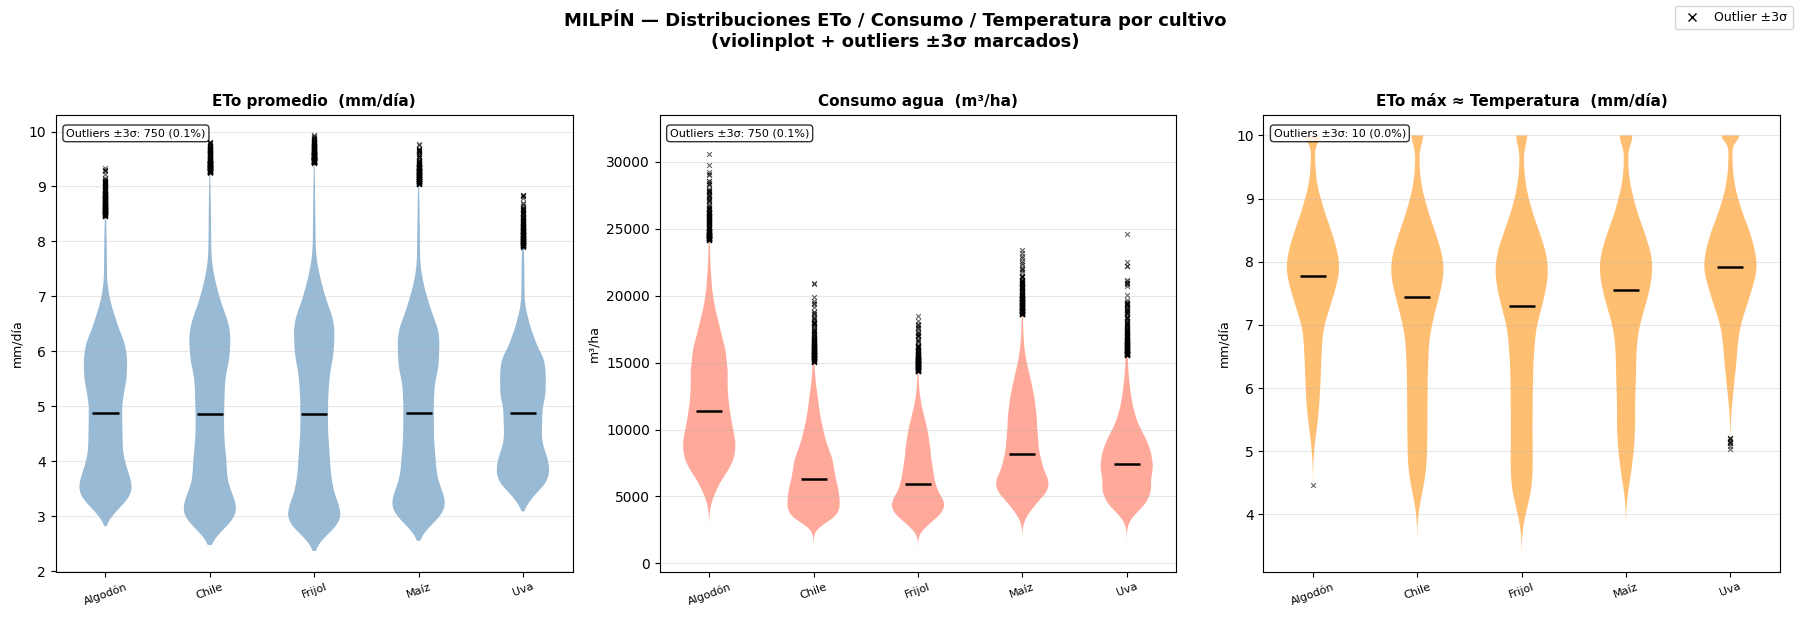

Outliers ±3σ globales (sobre todos los cultivos):
  ETo promedio  (mm/día)                  :   1,767  (0.29%)
  Consumo agua  (m³/ha)                   :   5,296  (0.88%)
  ETo máx ≈ Temperatura  (mm/día)         :      15  (0.00%)


In [10]:
# ── SLIDE 6: Distribuciones ETo / Consumo agua / Temperatura ──────────────────
# Violinplots por cultivo con outliers ±3σ marcados explícitamente.
# "temperatura" → et0_maximo_mmdia (proxy; Penman-Monteith lo hace dependiente de T_max).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')

VARS = {
    'et0_promedio_mmdia':       ('ETo promedio  (mm/día)',       'steelblue'),
    'volumen_agua_total_m3_ha': ('Consumo agua  (m³/ha)',        'tomato'),
    'et0_maximo_mmdia':         ('ETo máx ≈ Temperatura  (mm/día)', 'darkorange'),
}

CULTIVOS  = sorted(df['cultivo'].unique())
N_CULTIVO = len(CULTIVOS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, (label, color)) in zip(axes, VARS.items()):
    data_by_c = [df.loc[df['cultivo'] == c, col].dropna().values for c in CULTIVOS]

    # Violin
    parts = ax.violinplot(data_by_c, positions=range(N_CULTIVO),
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    # Outliers ±3σ por cultivo
    outlier_x, outlier_y = [], []
    for i, (c, vals) in enumerate(zip(CULTIVOS, data_by_c)):
        mu, sigma = vals.mean(), vals.std()
        mask = (vals < mu - 3*sigma) | (vals > mu + 3*sigma)
        outs = vals[mask]
        if len(outs):
            # muestra máx 150 outliers para no saturar
            sample_idx = np.random.choice(len(outs), min(150, len(outs)), replace=False)
            outlier_x.extend([i] * len(sample_idx))
            outlier_y.extend(outs[sample_idx])

    ax.scatter(outlier_x, outlier_y, color='black', s=12, zorder=5,
               alpha=0.6, marker='x', linewidths=0.8)

    ax.set_xticks(range(N_CULTIVO))
    ax.set_xticklabels(CULTIVOS, fontsize=8, rotation=20)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label.split('(')[1].replace(')', '') if '(' in label else '', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Anotación del conteo total de outliers
    n_out = len(outlier_y)
    pct   = n_out / len(df) * 100
    ax.text(0.02, 0.97, f'Outliers ±3σ: {n_out:,} ({pct:.1f}%)',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

outlier_marker = mlines.Line2D([], [], color='black', marker='x', linestyle='None',
                                markersize=6, label='Outlier ±3σ')
fig.legend(handles=[outlier_marker], loc='upper right', fontsize=9)

plt.suptitle('MILPÍN — Distribuciones ETo / Consumo / Temperatura por cultivo\n'
             '(violinplot + outliers ±3σ marcados)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide6_distribuciones_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen outliers por variable
print('Outliers ±3σ globales (sobre todos los cultivos):')
for col, (label, _) in VARS.items():
    serie = df[col].dropna()
    mu, sigma = serie.mean(), serie.std()
    n_out = ((serie < mu - 3*sigma) | (serie > mu + 3*sigma)).sum()
    print(f'  {label:<40s}: {n_out:>7,}  ({n_out/len(df)*100:.2f}%)')


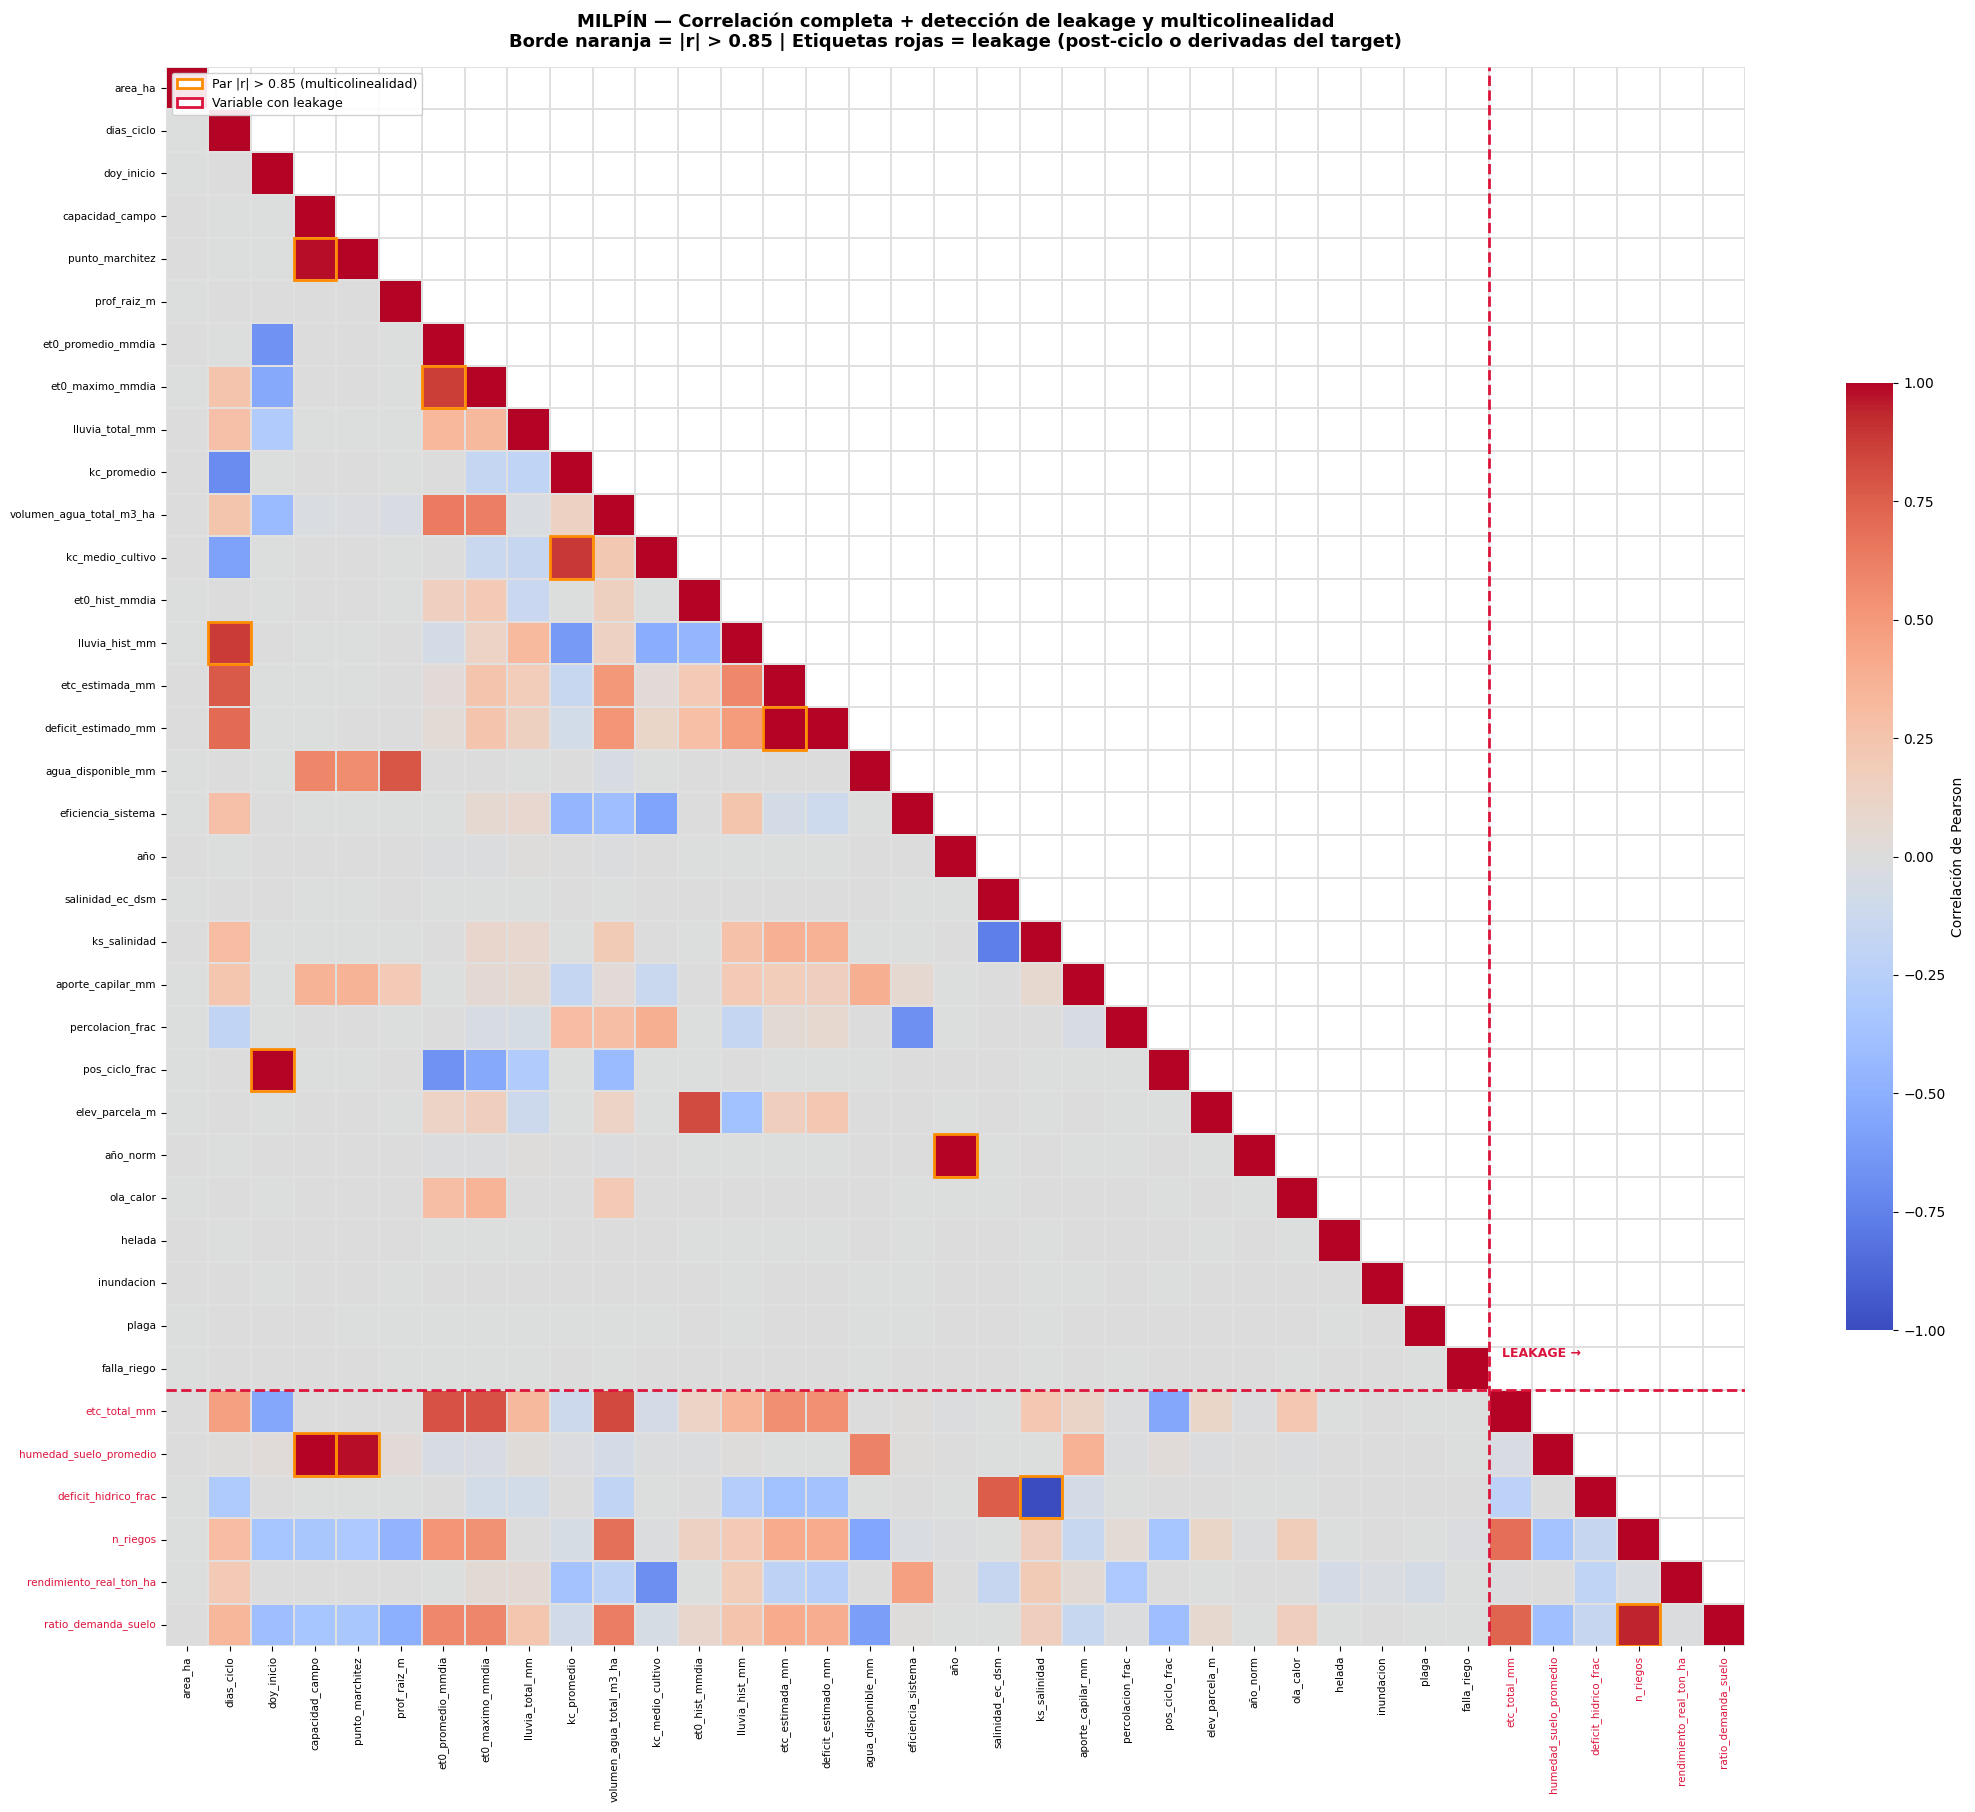

  PARES CON |r| > 0.85  (multicolinealidad)
  +0.880  dias_ciclo                           ↔  lluvia_hist_mm
  +1.000  doy_inicio                           ↔  pos_ciclo_frac
  +0.984  capacidad_campo                      ↔  punto_marchitez
  +0.993  capacidad_campo                      ↔  humedad_suelo_promedio ← LEAKAGE
  +0.982  punto_marchitez                      ↔  humedad_suelo_promedio ← LEAKAGE
  +0.869  et0_promedio_mmdia                   ↔  et0_maximo_mmdia
  +0.887  kc_promedio                          ↔  kc_medio_cultivo
  +0.994  etc_estimada_mm                      ↔  deficit_estimado_mm
  +1.000  año                                  ↔  año_norm
  -1.000  ks_salinidad                         ↔  deficit_hidrico_frac ← LEAKAGE
  +0.939  n_riegos                             ↔  ratio_demanda_suelo ← LEAKAGE

  VARIABLES DE LEAKAGE IDENTIFICADAS:
    deficit_hidrico_frac                 r_target=-0.195
    etc_total_mm                         r_target=+0.831
    humedad_suelo

In [9]:
# ── SLIDE 7: Leakage + multicolinealidad ──────────────────────────────────────
# Matriz de correlación completa. Pares > 0.85 con borde naranja.
# Variables con leakage (conocidas solo post-ciclo o derivadas del target) en rojo.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

df = pd.read_csv('../../data/synthetic/milpin_ciclos_ml.csv')

# Variables con leakage respecto a predecir volumen_agua_total_m3_ha ANTES del ciclo:
#   etc_total_mm      → ETc real acumulado (calculado al final del ciclo con Kc real)
#   n_riegos          → resultado de la decisión de riego (variable objetivo operacional)
#   rendimiento_real_ton_ha → post-cosecha
#   deficit_hidrico_frac    → balance medido durante el ciclo completo
#   humedad_suelo_promedio  → promedio acumulado del ciclo
#   ratio_demanda_suelo     → derivado de n_riegos y volumen (alta corr 0.94)
LEAKAGE = {
    'etc_total_mm',
    'n_riegos',
    'rendimiento_real_ton_ha',
    'deficit_hidrico_frac',
    'humedad_suelo_promedio',
    'ratio_demanda_suelo',
}

nums = df.select_dtypes(include='number').columns.tolist()
corr = df[nums].corr()

# Orden: leakage al final para que se vea agrupado
ordered = [c for c in nums if c not in LEAKAGE] + [c for c in nums if c in LEAKAGE]
corr = corr.loc[ordered, ordered]

# ── Figura ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # sólo triángulo inferior
sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.6, 'label': 'Correlación de Pearson'},
    square=True,
)

n = len(ordered)

# Resaltar pares > |0.85| con borde naranja
for i, row_var in enumerate(ordered):
    for j, col_var in enumerate(ordered):
        if j >= i:               # triángulo superior enmascarado
            continue
        if abs(corr.loc[row_var, col_var]) > 0.85:
            ax.add_patch(patches.Rectangle(
                (j, i), 1, 1,
                fill=False, edgecolor='darkorange', linewidth=2.0, zorder=4
            ))

# Etiquetas de leakage en rojo
tick_colors_x, tick_colors_y = [], []
for lbl in ax.get_xticklabels():
    lbl.set_color('crimson' if lbl.get_text() in LEAKAGE else 'black')
    lbl.set_fontsize(7.5)
for lbl in ax.get_yticklabels():
    lbl.set_color('crimson' if lbl.get_text() in LEAKAGE else 'black')
    lbl.set_fontsize(7.5)

# Línea separadora leakage vs features
n_safe = len([c for c in ordered if c not in LEAKAGE])
ax.axhline(n_safe, color='crimson', linewidth=2.0, linestyle='--', zorder=5)
ax.axvline(n_safe, color='crimson', linewidth=2.0, linestyle='--', zorder=5)
ax.text(n_safe + 0.3, n_safe - 1.0, 'LEAKAGE →', color='crimson',
        fontsize=9, fontweight='bold', va='top')

ax.set_title('MILPÍN — Correlación completa + detección de leakage y multicolinealidad\n'
             'Borde naranja = |r| > 0.85 | Etiquetas rojas = leakage (post-ciclo o derivadas del target)',
             fontsize=13, fontweight='bold', pad=14)

legend_handles = [
    patches.Patch(facecolor='white', edgecolor='darkorange', linewidth=2, label='Par |r| > 0.85 (multicolinealidad)'),
    patches.Patch(facecolor='white', edgecolor='crimson',    linewidth=2, label='Variable con leakage'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('slide7_leakage_multicolinealidad.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Reporte de pares multicolineales ──────────────────────────────
print('=' * 65)
print('  PARES CON |r| > 0.85  (multicolinealidad)')
print('=' * 65)
vistos = set()
for i, a in enumerate(ordered):
    for b in ordered[i+1:]:
        v = corr.loc[a, b]
        if abs(v) > 0.85 and (a, b) not in vistos:
            vistos.add((a, b))
            leak_flag = ' ← LEAKAGE' if a in LEAKAGE or b in LEAKAGE else ''
            print(f'  {v:+.3f}  {a:<35s}  ↔  {b}{leak_flag}')

print()
print('  VARIABLES DE LEAKAGE IDENTIFICADAS:')
for v in sorted(LEAKAGE):
    corr_target = corr.loc[v, 'volumen_agua_total_m3_ha']
    print(f'    {v:<35s}  r_target={corr_target:+.3f}')
print('=' * 65)
